# Who Ruled Formula 1? A 75-Year Data Story

## Introduction

This notebook explores 75 years of Formula 1 history using the [Formula 1 World Championship Dataset](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020), 
a comprehensive database covering every race, driver, constructor, and circuit from 1950 to 2024.

The analysis is based on 5 tables from the database, whose structure is shown below:

<img src="images/ERD.png" width="800">

The SQLite database was built from raw CSV files using `create_db.py`. 
For data quality checks and table structure overview, see `data_overview.ipynb`.

### The analysis answers four key questions:
- How has Formula 1 grown over the decades?
- Which constructors dominated and in which eras?
- Who were the greatest drivers ?
- What do circuits tell us about danger and overtaking opportunities?

## Imports

In [1]:
import pandas as pd
import sqlite3 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect("db/formula1.db")

## Visualisation params

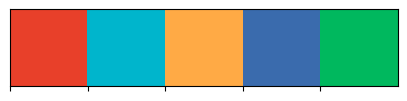

In [3]:
f1_palette = [
    '#E8402A', 
    '#00B5CC',  
    '#FFAA45',  
    '#3A6BAD',  
    '#00B85E',  
]

sns.palplot(sns.color_palette(f1_palette))
plt.show()

In [4]:
sns.set_theme(
    style='white',      
    palette=f1_palette,   
    font='monospace',     
    font_scale=1.2         
)

In [5]:
plt.rcParams['figure.figsize'] = (12, 6) 
plt.rcParams['axes.titlesize'] = 14      
plt.rcParams['axes.labelsize'] = 10      
plt.rcParams['figure.facecolor'] = 'white' 
plt.rcParams['axes.facecolor'] = '#F5F5F0'  
plt.rcParams['figure.facecolor'] = '#F5F5F0'

## 1. The Big Picture

### How has Formula 1 grown over the decades?

In [6]:
query = """ 
WITH decade_stats AS (
        SELECT 
        (year / 10) * 10 AS decade,
        COUNT(DISTINCT ra.raceId) AS total_races,
        COUNT(DISTINCT ra.circuitId) AS unique_circuits,
        COUNT(DISTINCT re.driverId) AS unique_drivers,
        COUNT(DISTINCT re.constructorId) AS unique_constructors
        FROM races ra
        JOIN results re ON ra.raceId = re.raceId
        GROUP BY (year / 10) * 10
)
        SELECT
        decade,
        total_races,
        unique_circuits,
        unique_drivers,
        unique_constructors,
        COALESCE( total_races - LAG(total_races) OVER (ORDER BY decade), 0) AS races_growth,
        COALESCE(unique_circuits - LAG(unique_circuits) OVER (ORDER BY decade), 0) AS circuits_growth,
        COALESCE(unique_drivers - LAG(unique_drivers) OVER (ORDER BY decade), 0) AS drivers_growth,
        COALESCE(unique_constructors - LAG(unique_constructors) OVER (ORDER BY decade), 0) AS constructors_growth
        FROM decade_stats
        ORDER BY decade
        """

df = pd.read_sql(query, conn)
df

,decade,total_races,unique_circuits,unique_drivers,unique_constructors,races_growth,circuits_growth,drivers_growth,constructors_growth
0,1950,84,19,332,69,0,0,0,0
1,1960,100,25,219,71,16,6,-113,2
2,1970,144,28,173,55,44,3,-46,-16
3,1980,156,31,115,31,12,3,-58,-24
4,1990,162,26,105,33,6,-5,-10,2
5,2000,174,24,71,23,12,-2,-34,-10
6,2010,198,27,66,19,24,3,-5,-4
7,2020,107,30,36,14,-91,3,-30,-5


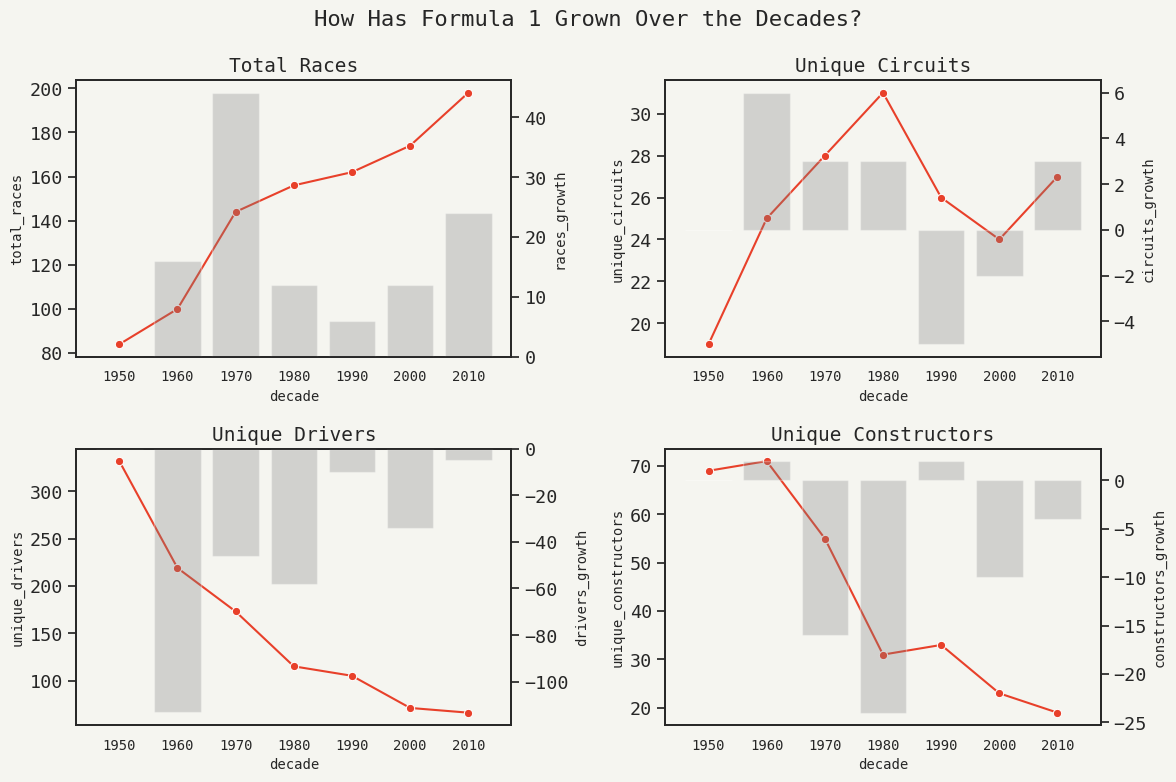

In [7]:
df['decade'] = df['decade'].astype(str)
df = df[df['decade'] != '2020']
# Note: The 2020s decade is excluded from this analysis as it is incomplete (2020–2024 only).
# Including it would underrepresent the decade compared to full 10-year periods.
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# races
ax1_twin = ax1.twinx()
sns.barplot(data=df, x='decade', y='races_growth', ax=ax1_twin, alpha=0.3, color='gray')
sns.lineplot(data=df, x='decade', y='total_races', ax=ax1, marker='o')
ax1.set_title('Total Races')
ax1.tick_params(axis='x', labelsize=10)

# unique circuits
ax2_twin = ax2.twinx()
sns.barplot(data=df, x='decade', y='circuits_growth', ax=ax2_twin, alpha=0.3, color='gray')
sns.lineplot(data=df, x='decade', y='unique_circuits', ax=ax2, marker='o')
ax2.set_title('Unique Circuits')
ax2.tick_params(axis='x', labelsize=10)  

# unique drivers
ax3_twin = ax3.twinx()
sns.barplot(data=df, x='decade', y='drivers_growth', ax=ax3_twin, alpha=0.3, color='gray')
sns.lineplot(data=df, x='decade', y='unique_drivers', ax=ax3, marker='o')
ax3.set_title('Unique Drivers')
ax3.tick_params(axis='x', labelsize=10)

# unique constructors
ax4_twin = ax4.twinx()
sns.barplot(data=df, x='decade', y='constructors_growth', ax=ax4_twin, alpha=0.3, color='gray')
sns.lineplot(data=df, x='decade', y='unique_constructors', ax=ax4, marker='o')
ax4.set_title('Unique Constructors')
ax4.tick_params(axis='x', labelsize=10)

plt.suptitle('How Has Formula 1 Grown Over the Decades?', fontsize=16)
plt.tight_layout()
plt.show()

The number of races rocketed from 84 in the 1950s to 198 in the 2010s, with the steepest growth occurring between 1950 and 1970 (+60 races).  

The circuit count peaked in the 1980s (31 unique venues) and has declined since, suggesting F1 shifted towards a smaller set of established, recurring venues rather than adding new locations.  

The most dramatic shift is the drop in unique drivers and constructors -from 332 drivers and 69 constructors in the 1950s to just 66 and 19 in the 2010s. This reflects the increasing cost and demands for F1 and shows how exclusive the sport is becoming.

### In which years the cars were the fastest?

> Note: some years do not have data regarding speed

In [8]:
query = """
WITH yearly_avg_speed AS(
    SELECT
    ra.year,
    AVG(CAST(re.fastestLapSpeed AS FLOAT)) AS avg_speed
    FROM races ra
    INNER JOIN results re ON re.raceId = ra.raceId
    WHERE re.fastestLapSpeed IS NOT NULL
    AND re.fastestLapSpeed != '\\N'
    AND CAST(re.fastestLapSpeed AS FLOAT) > 0
    GROUP BY ra.year
),
ntile_ranking AS(
    SELECT
    year,
    avg_speed,
    NTILE(4) OVER(ORDER BY avg_speed DESC) AS quartile
    FROM yearly_avg_speed
)
    SELECT
    year,
    ROUND(avg_speed, 2) AS avg_speed,
    quartile,
    CASE quartile
        WHEN 1 THEN 'fastest'
        WHEN 2 THEN 'above average'
        WHEN 3 THEN 'below average'
        WHEN 4 THEN 'slowest'
    END AS speed_category
    FROM ntile_ranking
    ORDER BY year
"""

df = pd.read_sql(query, conn)
df

,year,avg_speed,quartile,speed_category
0,2004,211.74,1,fastest
1,2005,210.24,1,fastest
2,2006,205.18,2,above average
3,2007,203.08,3,below average
4,2008,201.82,3,below average
5,2009,202.21,3,below average
6,2010,197.66,3,below average
7,2011,195.74,4,slowest
8,2012,196.49,4,slowest
9,2013,198.28,3,below average


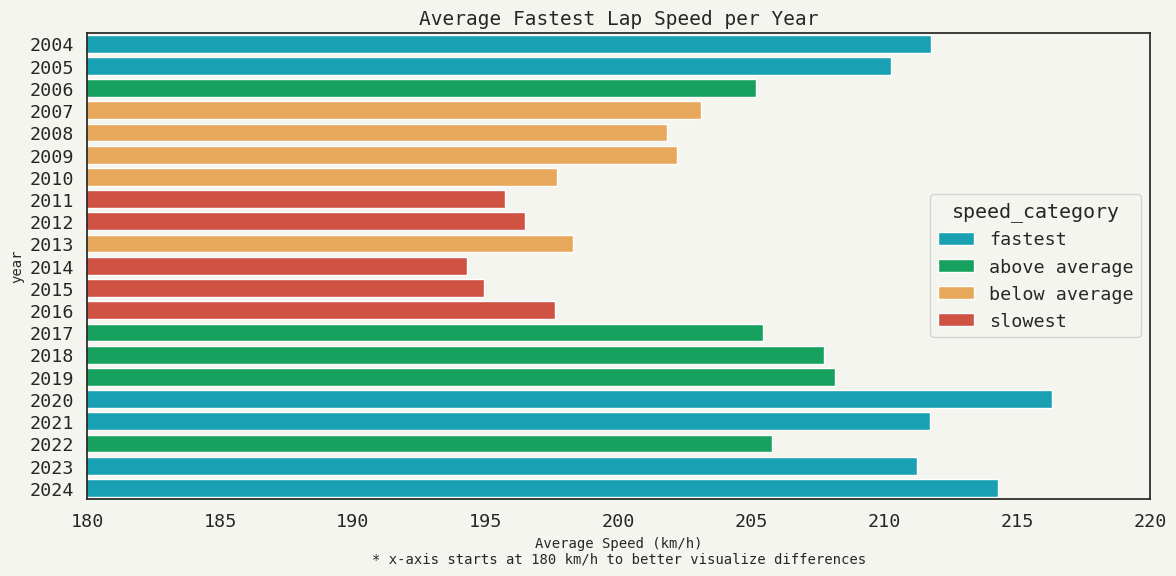

In [9]:
fig, ax = plt.subplots()
sns.barplot(data=df,  x='avg_speed', y='year',  orient='h', hue='speed_category',
            ax=ax,
            palette= {'fastest': '#00B5CC', 
                     'above average': '#00B85E',
                     'below average': '#FFAA45', 
                     'slowest': '#E8402A'})
ax.set_title('Average Fastest Lap Speed per Year')
ax.set_xlabel('Average Speed (km/h)\n* x-axis starts at 180 km/h to better visualize differences')
ax.set_ylabel('year')
ax.set_xlim(180, 220) 
plt.tight_layout()
plt.show()

The chart shows the average fastest lap speed across all drivers per year. The slowest period was 2011–2016 because of major regulation changes.

Speeds recovered after 2017, with 2020 recording the highest average at 216 km/h, surpassing even the V10 era of 2004–2005.

### Which decades had the most races in Formula 1 history?

In [10]:
query = """ 
        SELECT 
        (year / 10) * 10 AS decade,
        RANK() OVER(ORDER BY COUNT(DISTINCT ra.raceId) DESC) as busiest_decade_rank,
        COUNT(DISTINCT ra.raceId) AS total_races
        FROM races ra
        GROUP BY (year / 10) * 10
        ORDER BY decade
        """

df = pd.read_sql(query, conn)
df

,decade,busiest_decade_rank,total_races
0,1950,8,84
1,1960,7,100
2,1970,5,144
3,1980,4,156
4,1990,3,162
5,2000,2,174
6,2010,1,198
7,2020,6,107


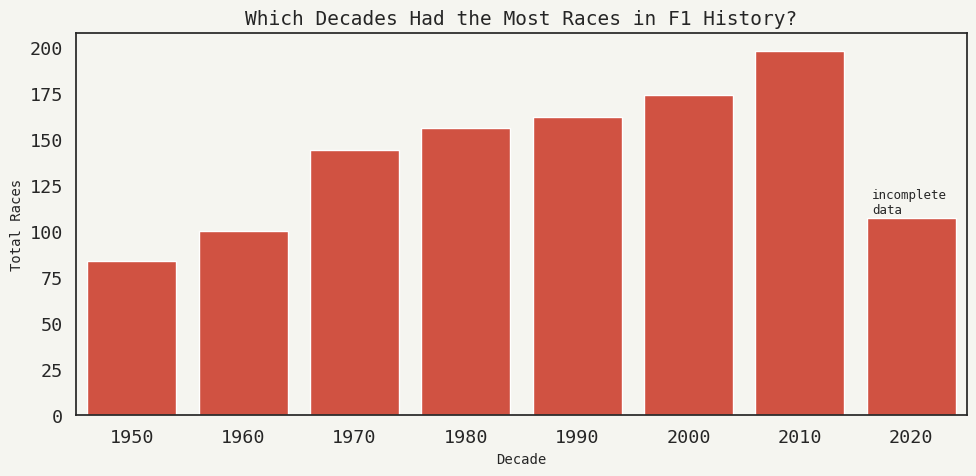

In [11]:
df['decade'] = df['decade'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='decade', y='total_races', ax=ax)
ax.set_title('Which Decades Had the Most Races in F1 History?')
ax.set_xlabel('Decade')
ax.set_ylabel('Total Races')
ax.text(6.65, 110, 'incomplete\ndata', fontsize=9)
# Note: The 2020s decade is incomplete (2020–2024 only).

plt.tight_layout()
plt.show()

The 2010s were the busiest decade in F1 history with 198 races, followed by the 2000s (174) and 1990s (162). There is a clear upward trend since 1950.

### Quick summary statistics

In [12]:
query = """
    SELECT
        COUNT(DISTINCT raceId) AS total_races,
        COUNT(DISTINCT circuitId) AS total_circuits,
        MIN(year) AS first_season,
        MAX(year) AS last_season
    FROM races
"""

pd.read_sql(query, conn)

,total_races,total_circuits,first_season,last_season
0,1125,77,1950,2024


## 2. Constructor Dynasties

### How many race entries have the most popular constructors made in F1 history?

In [13]:
query = """ 
with constructor_stats as(
        SELECT 
        c.name,
        count(*) as total_entries
        FROM constructors c
        INNER JOIN results re on re.constructorId=c.constructorId
        GROUP BY c.constructorId
)
        SELECT 
        RANK() OVER(ORDER BY total_entries DESC) as entry_rank,
        name,
        total_entries
        FROM constructor_stats
        LIMIT 10
        """

df = pd.read_sql(query, conn)
df

,entry_rank,name,total_entries
0,1,Ferrari,2439
1,2,McLaren,1923
2,3,Williams,1676
3,4,Tyrrell,881
4,5,Team Lotus,871
5,6,Sauber,837
6,7,Red Bull,788
7,8,Renault,787
8,9,Minardi,672
9,10,Brabham,662


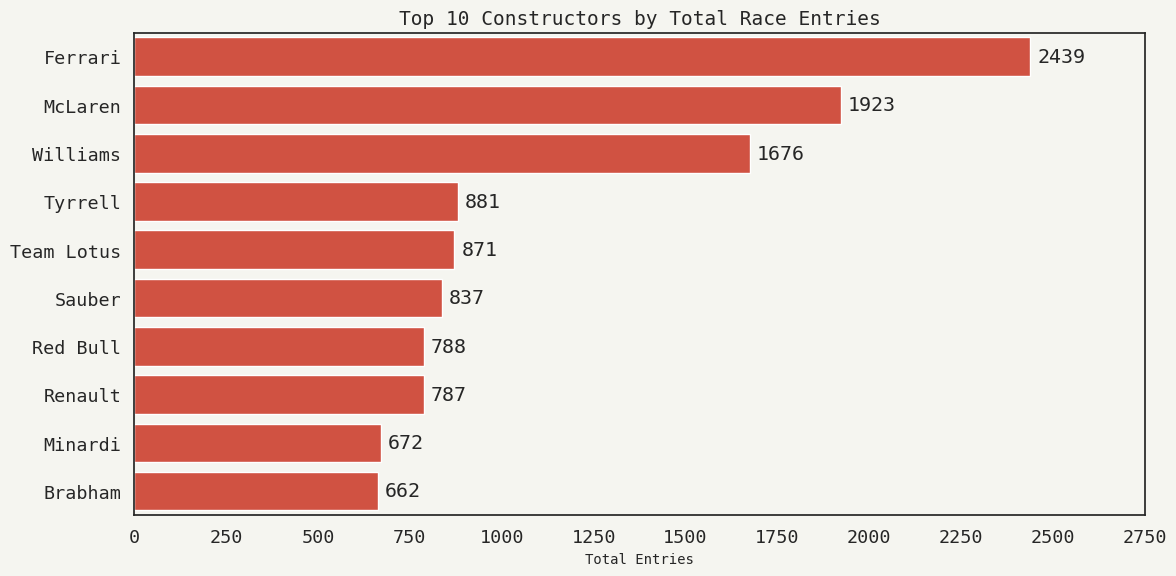

In [14]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='name', x='total_entries', ax=ax)
ax.bar_label(ax.containers[0], padding=5)
ax.set_title('Top 10 Constructors by Total Race Entries')
ax.set_xlabel('Total Entries')
ax.set_ylabel('')
ax.set_xticks(np.arange(0, 3000, 250))
plt.tight_layout()
plt.show()

Ferrari leads in the number of race entries with 2,439 entries, which is over 500 more than McLaren (1,923) and Williams (1,676).  

The remaining 7 constructors have between 662 and 881 entries, highlighting the dominance of the top three.

### Which constructors won the most races?

In [15]:
query = """ 
WITH constructor_wins AS (
        SELECT 
        c.constructorId,
        c.name,
        COUNT(*) AS total_wins
        FROM constructors c
        INNER JOIN results re ON re.constructorId = c.constructorId
        INNER JOIN races ra ON re.raceId = ra.raceId
        WHERE re.position = 1
        GROUP BY c.constructorId
),
ranked AS (
        SELECT 
        RANK() OVER(ORDER BY total_wins DESC) AS win_rank,
        name,
        total_wins
        FROM constructor_wins
)
        SELECT *
        FROM ranked
        WHERE win_rank <= 10
        ORDER BY win_rank
"""

df = pd.read_sql(query, conn)
df

,win_rank,name,total_wins
0,1,Ferrari,249
1,2,McLaren,185
2,3,Mercedes,129
3,4,Red Bull,122
4,5,Williams,114
5,6,Team Lotus,45
6,7,Renault,35
7,8,Benetton,27
8,9,Tyrrell,23
9,9,Brabham,23


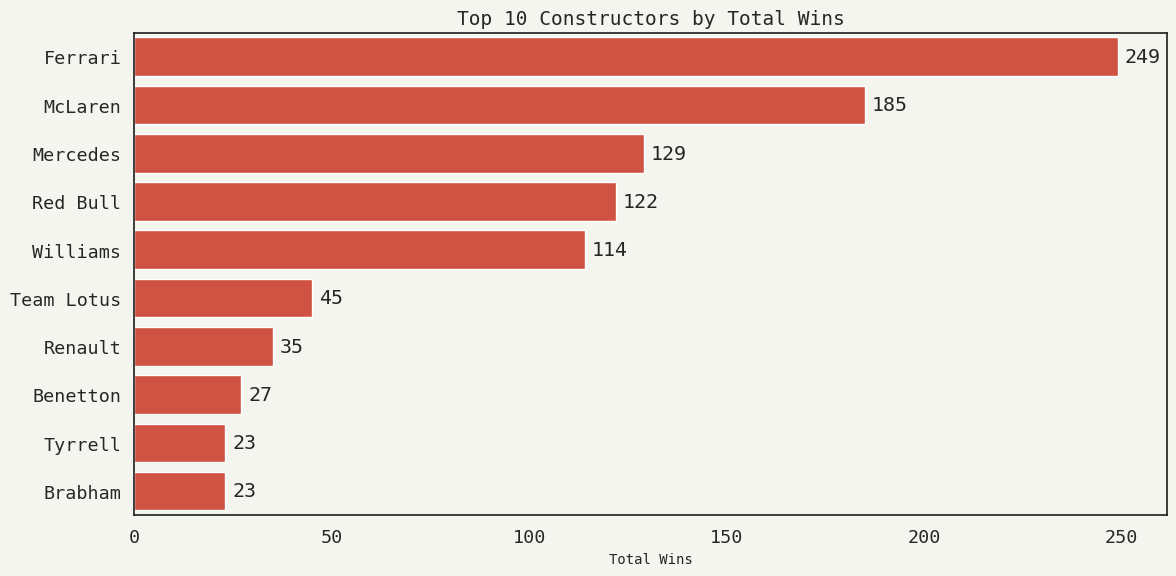

In [16]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='name', x='total_wins', ax=ax)
ax.bar_label(ax.containers[0], padding=5)
ax.set_title('Top 10 Constructors by Total Wins')
ax.set_xlabel('Total Wins')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Compared to the previous chart, more entries do not always mean more wins. Red Bull (7th in entries) jumps to 4th in wins, and Mercedes - not even in the top 10 entries - reaches 3rd, reflecting their recent dominance.

### What is the relationship between race entries and total wins per constructor per seasons?

In [17]:
query = """ 
        SELECT
        ra.year,
        c.name,
        COUNT(*) AS total_entries,
        SUM(CASE WHEN re.position = 1 THEN 1 ELSE 0 END) AS total_wins
        FROM results re
        JOIN constructors c ON c.constructorId = re.constructorId
        JOIN races ra ON ra.raceId = re.raceId
        GROUP BY re.constructorId, ra.year
"""


df = pd.read_sql(query, conn)
df

,year,name,total_entries,total_wins
0,1968,McLaren,2,0
1,1971,McLaren,27,0
2,1972,McLaren,25,1
3,1973,McLaren,35,3
4,1974,McLaren,46,4
...,...,...,...,...
1106,2021,Alpine F1 Team,44,1
1107,2022,Alpine F1 Team,44,0
1108,2023,Alpine F1 Team,44,0
1109,2024,Alpine F1 Team,48,0


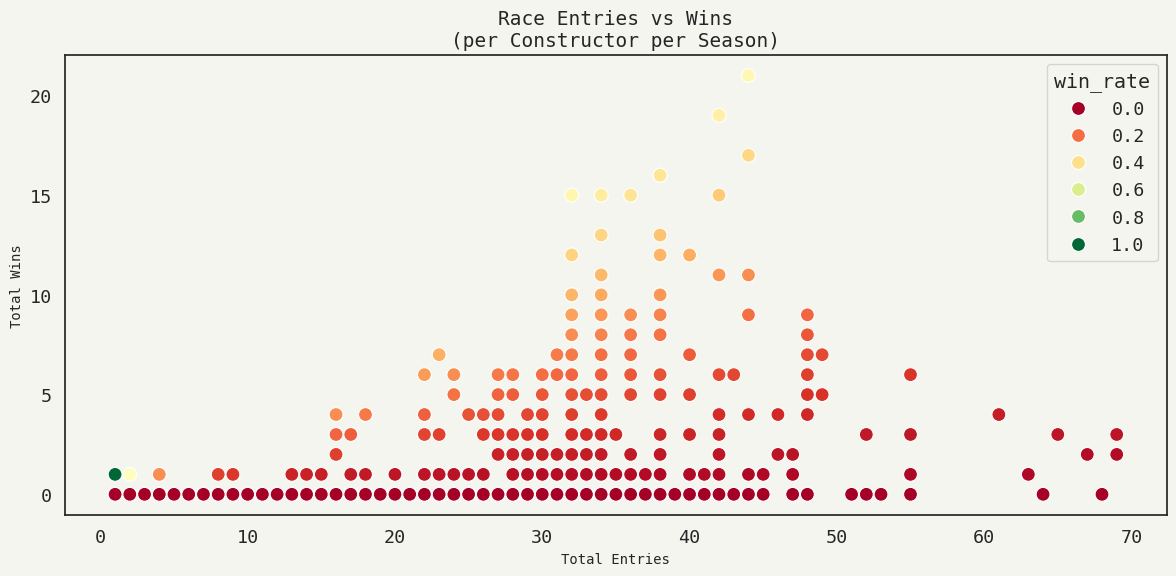

In [18]:
df['win_rate'] = df['total_wins'] / df['total_entries']

fig, ax = plt.subplots()
sns.scatterplot(data=df, x='total_entries', y='total_wins', 
                hue='win_rate',
                palette='RdYlGn',s=100, ax=ax)
ax.set_title('Race Entries vs Wins\n(per Constructor per Season)')
ax.set_xlabel('Total Entries')
ax.set_ylabel('Total Wins')
plt.tight_layout()
plt.show()

The vast majority of constructors win 0 races per season, regardless of how many entries they make. Only a small group of constructors with 30–45 entries per season 
achieve higher win rates (yellow), suggesting that consistency and experience matter more than number of entries.

### Which constructors dominated (in terms of total_wins) each decade of Formula 1?

In [19]:
query = """ 
WITH constructor_wins AS (
        SELECT 
        (ra.year / 10) * 10 AS decade,
        c.name,
        COUNT(*) AS total_wins
        FROM constructors c
        INNER JOIN results re ON re.constructorId = c.constructorId
        INNER JOIN races ra ON re.raceId = ra.raceId
        WHERE re.position = 1
        GROUP BY c.constructorId, decade
),
ranked AS (
        SELECT 
        decade,
        RANK() OVER(PARTITION BY decade ORDER BY total_wins DESC) AS win_rank,
        name,
        total_wins
        FROM constructor_wins
)
        SELECT *
        FROM ranked
        WHERE win_rank <= 3
        ORDER BY decade, win_rank
"""

df = pd.read_sql(query, conn)
df

,decade,win_rank,name,total_wins
0,1950,1,Ferrari,30
1,1950,2,Alfa Romeo,11
2,1950,3,Vanwall,10
3,1960,1,Lotus-Climax,22
4,1960,2,Ferrari,13
5,1960,3,BRM,12
6,1970,1,Ferrari,37
7,1970,2,Team Lotus,35
8,1970,3,Tyrrell,21
9,1980,1,McLaren,56


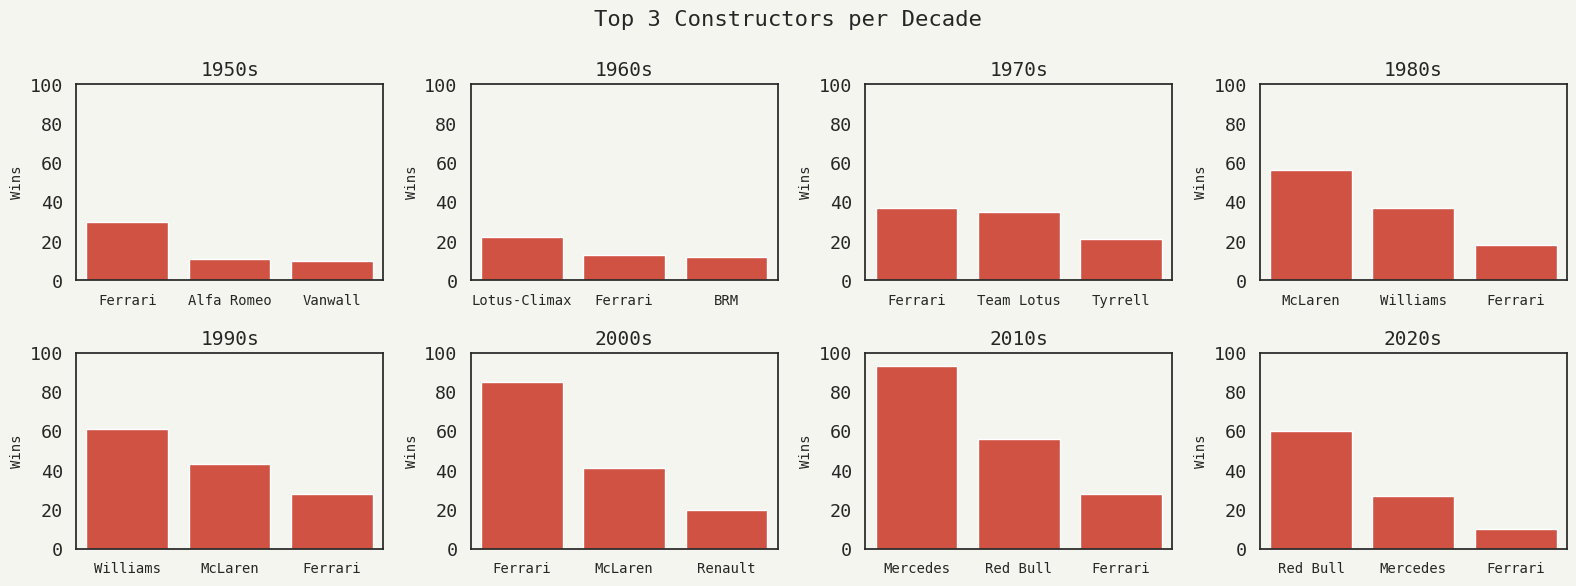

In [20]:
decades = df['decade'].unique()

fig, axes = plt.subplots(2, 4, figsize=(16,6))
axes = axes.flatten()
ticks = np.arange(0,120,20)

for i, decade in enumerate(sorted(decades)):
    decade_df = df[df['decade'] == decade]
    sns.barplot(data=decade_df, x='name', y='total_wins', ax=axes[i])
    axes[i].set_title(f'{decade}s')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Wins')
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].set_yticks(ticks)

plt.suptitle('Top 3 Constructors per Decade', fontsize=16)
plt.tight_layout()
plt.show()

Dominance in F1 shifts every decade - from McLaren in the 1980s, Williams in the 1990s, Ferrari in the 2000s, to Mercedes in the 2010s and Red Bull today.
Ferrari is the only constructor to appear in every decade's top 3, making them the ultimate symbol of long-term success in F1.

Note: The 2020s are incomplete (2020–2024 only).

## 3. Greatest Drivers

### Who are the all-time top 10 drivers by points, wins and podiums? 

In [21]:
query = """ 
WITH drivers_result_info AS(
       SELECT 
       d.driverId,
       d.forename,
       d.surname,
       re.points,
       CASE re.position
              WHEN 1 THEN 1
              ELSE 0
       END AS win,
       CASE 
              WHEN re.position BETWEEN 1 AND 3 THEN 1
              ELSE 0
       END AS podium
       FROM drivers d 
       INNER JOIN results re ON d.driverId = re.driverId
)
       SELECT
       RANK() OVER(ORDER BY SUM(points) DESC) AS rank,
       forename || ' ' || surname AS best_driver,
       SUM(points) AS total_points,
       SUM(win) AS total_wins,
       SUM(podium) AS total_podiums
       FROM drivers_result_info
       GROUP BY driverId
       ORDER BY rank
       LIMIT 10
"""

df = pd.read_sql(query, conn)
df

,rank,best_driver,total_points,total_wins,total_podiums
0,1,Lewis Hamilton,4820.5,105,220
1,2,Sebastian Vettel,3098.0,53,173
2,3,Max Verstappen,2912.5,63,122
3,4,Fernando Alonso,2329.0,32,183
4,5,Kimi Räikkönen,1873.0,21,170
5,6,Valtteri Bottas,1788.0,10,148
6,7,Nico Rosberg,1594.5,23,99
7,8,Sergio Pérez,1585.0,6,126
8,9,Michael Schumacher,1566.0,91,176
9,10,Charles Leclerc,1363.0,8,62


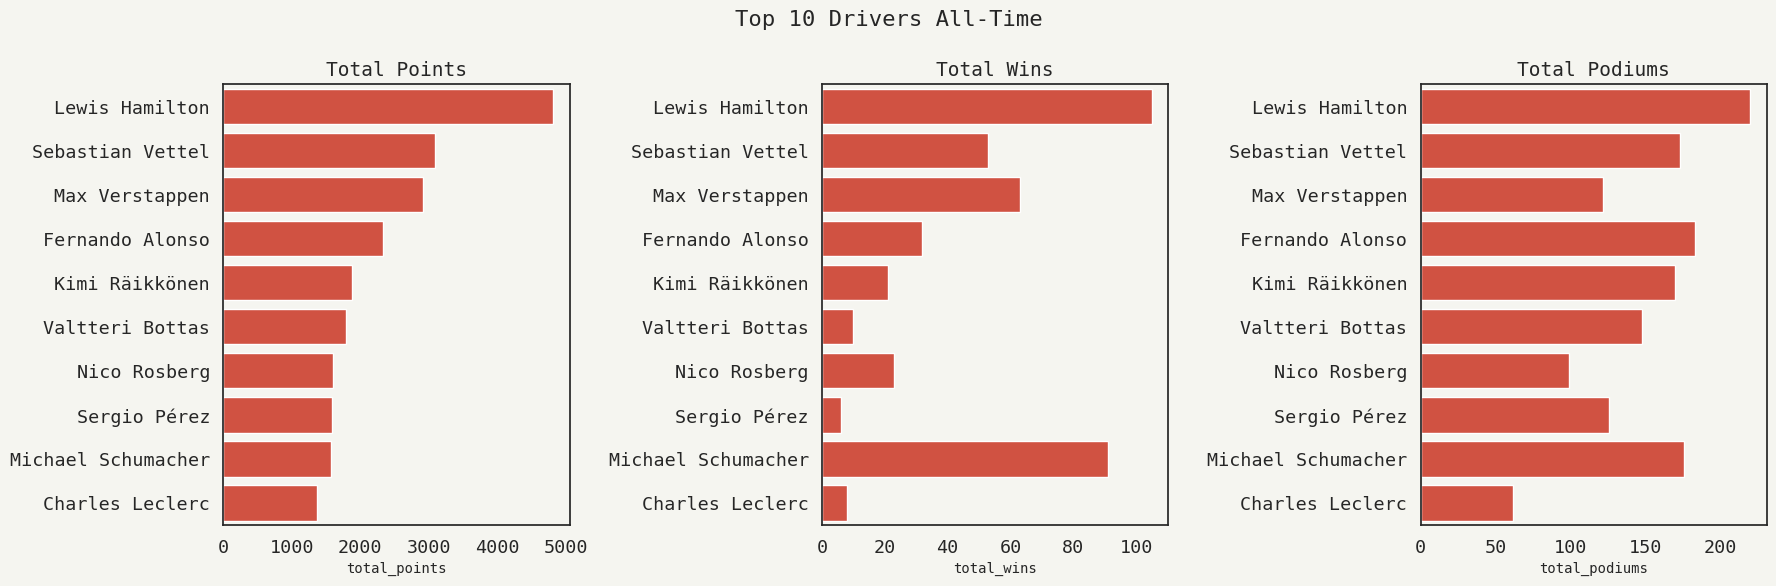

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=df, y='best_driver', x='total_points', ax=ax1)
ax1.set_title('Total Points')
ax1.set_ylabel('')

sns.barplot(data=df, y='best_driver', x='total_wins', ax=ax2)
ax2.set_title('Total Wins')
ax2.set_ylabel('')

sns.barplot(data=df, y='best_driver', x='total_podiums', ax=ax3)
ax3.set_title('Total Podiums')
ax3.set_ylabel('')

plt.suptitle('Top 10 Drivers All-Time', fontsize=16)
plt.tight_layout()
plt.show()

Lewis Hamilton leads all three categories — points (4,820), wins (105), and podiums (220) - making him the most decorated driver in F1 history.  

Notably, Michael Schumacher ranks 9th in points (1,566) but has 91 wins and 176 podiums. It is a result of the points system change in 2010 which  favours drivers of the modern era.

> **Note on points systems:** F1 has changed its points system multiple times throughout history. 
> The most significant change came in 2010, when the points awarded for a win increased from 10 to 25. 
> Total points should therefore not be used as the sole measure of a driver's greatness across different eras.

### How did the top 5 drivers accumulate points throughout their careers?

In [23]:
query = """ 
WITH top_5_drivers AS(
        SELECT 
        d.driverId,
        d.forename,
        d.surname,
        RANK() OVER(ORDER BY SUM(re.points) DESC) AS rank,
        SUM(re.points) as total_points
        FROM drivers d 
        INNER JOIN results re ON d.driverId = re.driverId
        GROUP BY d.driverID
        ORDER BY total_points DESC
        LIMIT 5
), points_and_dates AS(
        SELECT
        t.forename,
        t.surname,
        t.rank,
        year,
        SUM(SUM(re.points)) OVER(PARTITION BY t.driverId ORDER BY year ASC) AS accumulated_points
        FROM top_5_drivers t 
        INNER JOIN results re ON t.driverId = re.driverId
        INNER JOIN races ra ON ra.raceId = re.raceId
        GROUP BY t.driverId, year
)
        SELECT
        forename || ' ' || surname AS driver,
        year,
        accumulated_points
        FROM points_and_dates
        ORDER BY rank, year
        
"""

df = pd.read_sql(query, conn)
df

,driver,year,accumulated_points
0,Lewis Hamilton,2007,109.0
1,Lewis Hamilton,2008,207.0
2,Lewis Hamilton,2009,256.0
3,Lewis Hamilton,2010,496.0
4,Lewis Hamilton,2011,723.0
...,...,...,...
79,Kimi Räikkönen,2017,1565.0
80,Kimi Räikkönen,2018,1816.0
81,Kimi Räikkönen,2019,1859.0
82,Kimi Räikkönen,2020,1863.0


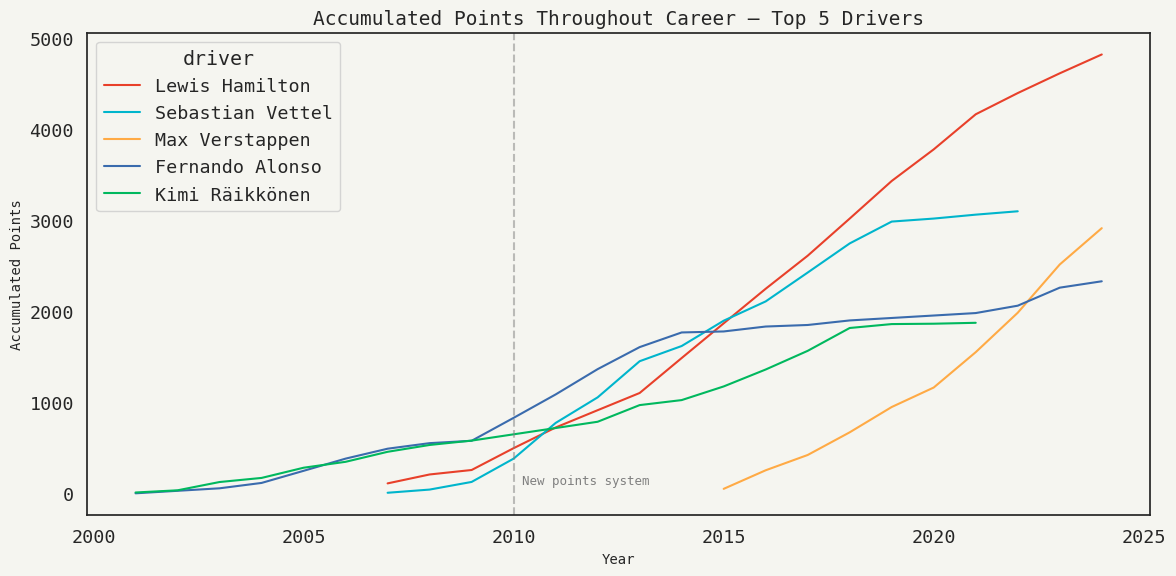

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df, x='year', y='accumulated_points', hue='driver', ax=ax)
ax.set_title('Accumulated Points Throughout Career — Top 5 Drivers')
ax.set_xlabel('Year')
ax.set_ylabel('Accumulated Points')
ax.axvline(x=2010, color='gray', linestyle='--', alpha=0.5)
ax.text(2010.2, 100, 'New points system', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

Hamilton's curve separates from the rest, reflecting his sustained dominance.

> Note: In 2010, F1 introduced a new points system  
> This explains the steeper accumulation curves after 2010 for all drivers.

### Which nationalities have the most points and who were their most successful drivers?

In [25]:
query = """ 
WITH best_nationalities AS(
    SELECT 
    d.nationality,
    SUM(re.points) as nationality_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY nationality
    ORDER BY nationality_points DESC
    LIMIT 10
), drivers_total_points AS(
    SELECT 
    d.driverId,
    d.forename,
    d.surname,
    d.nationality,
    SUM(points) AS driver_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY d.driverId
)
    SELECT
    b.nationality,
    b.nationality_points,
    d.forename || ' ' || d.surname as best_driver,
    d.driver_points as best_driver_total_points
    FROM best_nationalities b
    INNER JOIN drivers_total_points d ON b.nationality=d.nationality
    AND (d.driver_points,d.nationality) IN 
    (     
        SELECT
        MAX(driver_points),
        nationality
        FROM drivers_total_points
        GROUP BY nationality
    )
    ORDER BY nationality_points DESC
        """


df = pd.read_sql(query, conn)
df

,nationality,nationality_points,best_driver,best_driver_total_points
0,British,11908.64,Lewis Hamilton,4820.5
1,German,7988.50,Sebastian Vettel,3098.0
2,Finnish,4388.50,Kimi Räikkönen,1873.0
3,French,3636.33,Alain Prost,798.5
4,Spanish,3614.50,Fernando Alonso,2329.0
5,Brazilian,3423.00,Felipe Massa,1167.0
6,Australian,3188.50,Daniel Ricciardo,1320.0
7,Dutch,2941.50,Max Verstappen,2912.5
8,Italian,2040.66,Riccardo Patrese,281.0
9,Mexican,1679.00,Sergio Pérez,1585.0


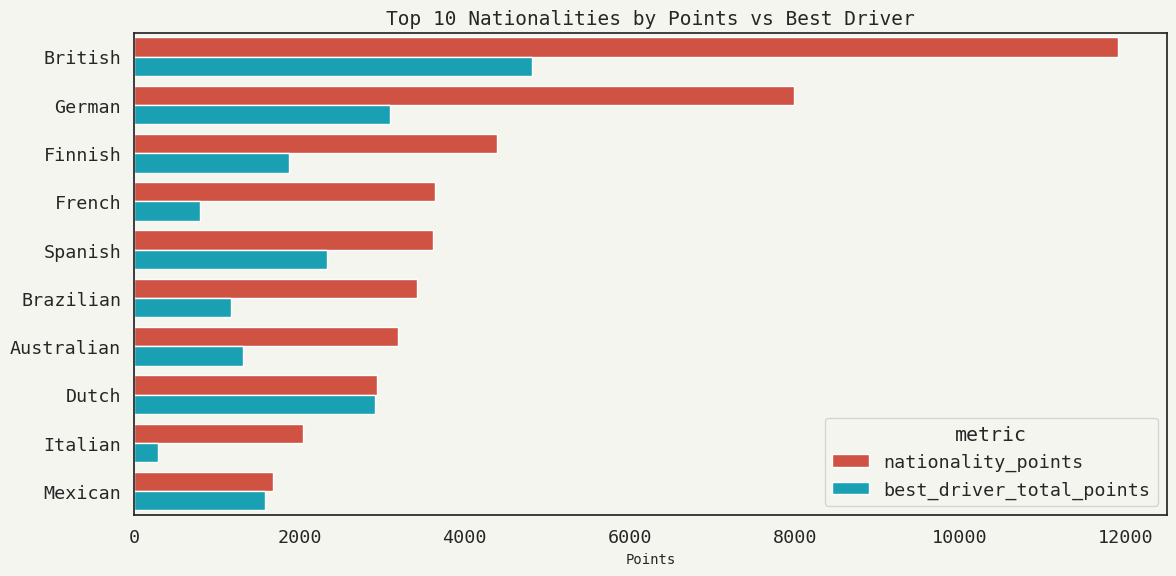

In [26]:
df_melted = df.melt(id_vars=['nationality', 'best_driver'],
                    value_vars=['nationality_points', 'best_driver_total_points'],
                    var_name='metric',
                    value_name='value')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_melted, y='nationality', x='value', hue='metric', ax=ax)
ax.set_title('Top 10 Nationalities by Points vs Best Driver')
ax.set_xlabel('Points')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

British drivers dominate with ~12,000 total points. It is boosted not only by Lewis Hamilton (4,820 points) but also by a strong pool of other British drivers.
In contrast, the Dutch total relies almost entirely on Max Verstappen (their gap between nationality points and best driver points is minimal).

### Which drivers scored above average points for their nationality?

In [27]:
query = """
WITH drivers_total_points AS(
    SELECT
    d.driverId,
    d.forename,
    d.surname,
    d.nationality,
    SUM(re.points) AS driver_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY d.driverId
)
    SELECT
    forename || ' ' || surname AS driver_name,
    nationality,
    driver_points
    FROM drivers_total_points d
    WHERE driver_points > (
        SELECT AVG(driver_points)
        FROM drivers_total_points d2
        WHERE d2.nationality = d.nationality
    )
    ORDER BY nationality, driver_points DESC
"""

pd.read_sql(query, conn)

,driver_name,nationality,driver_points
0,Mario Andretti,American,180.0
1,Dan Gurney,American,133.0
2,Richie Ginther,American,107.0
3,Phil Hill,American,98.0
4,Eddie Cheever,American,70.0
...,...,...,...
137,Jo Siffert,Swiss,68.0
138,Sébastien Buemi,Swiss,29.0
139,Marc Surer,Swiss,17.0
140,Alexander Albon,Thai,238.0


142 drivers scored above the average points for their nationality, meaning that in many countries only a small number of drivers, who carry the majority of the points (as seen in the Dutch case with Verstappen).

## 4. Circuits

###  Which circuits are the most and the least dangerous? 

In [28]:
# (R= Retired)
# We ignore circuits with less than a two hundred entries where DNF can be unstable

query = """ 
WITH circuit_retired_stats AS(
    SELECT 
    c.circuitId,
    c.circuitRef,
    c.name,
    COUNT(*) FILTER(WHERE re.positionText='R') AS retired,
    COUNT(*) AS all_entries,
    MIN(ra.year) AS first_appearance,
    MAX(ra.year) AS last_appearance
    FROM circuits c
    INNER JOIN races ra ON ra.circuitId = c.circuitId
    INNER JOIN results re ON re.raceId = ra.raceId
    GROUP BY c.circuitId
    HAVING COUNT(*) >= 200
)
    SELECT * FROM (  
        SELECT
        circuitRef,
        name,
        'most dangerous' as category,
        ROUND(retired * 100.0 / all_entries, 2) AS dnf_rate,
        retired,
        all_entries,
        first_appearance,
        last_appearance,
        CASE WHEN last_appearance < 2000 THEN 'historic' ELSE 'modern' END AS era
        FROM circuit_retired_stats
        ORDER BY dnf_rate DESC
        LIMIT 10 )
    UNION ALL
        SELECT * FROM(
        SELECT
        circuitRef,
        name,
        'least dangerous' as category,
        ROUND(retired * 100.0 / all_entries, 2) AS dnf_rate,
        retired,
        all_entries,
        first_appearance,
        last_appearance,
        CASE WHEN last_appearance < 2000 THEN 'historic' ELSE 'modern' END AS era
        FROM circuit_retired_stats
        ORDER BY dnf_rate ASC
        LIMIT 10 )
    ORDER BY dnf_rate DESC
"""

df = pd.read_sql(query, conn)
df

,circuitRef,name,category,dnf_rate,retired,all_entries,first_appearance,last_appearance,era
0,adelaide,Adelaide Street Circuit,most dangerous,47.12,147,312,1985,1995,historic
1,brands_hatch,Brands Hatch,most dangerous,45.45,170,374,1964,1986,historic
2,long_beach,Long Beach,most dangerous,45.00,99,220,1976,1983,historic
3,zolder,Zolder,most dangerous,43.62,123,282,1973,1984,historic
4,jacarepagua,Autódromo Internacional Nelson Piquet,most dangerous,42.66,122,286,1978,1989,historic
5,galvez,Autódromo Juan y Oscar Gálvez,most dangerous,41.96,188,448,1953,1998,historic
6,kyalami,Kyalami,most dangerous,41.90,212,506,1967,1993,historic
7,reims,Reims-Gueux,most dangerous,40.94,104,254,1950,1966,historic
8,indianapolis,Indianapolis Motor Speedway,most dangerous,40.84,234,573,1950,2007,modern
9,watkins_glen,Watkins Glen,most dangerous,40.21,195,485,1961,1980,historic


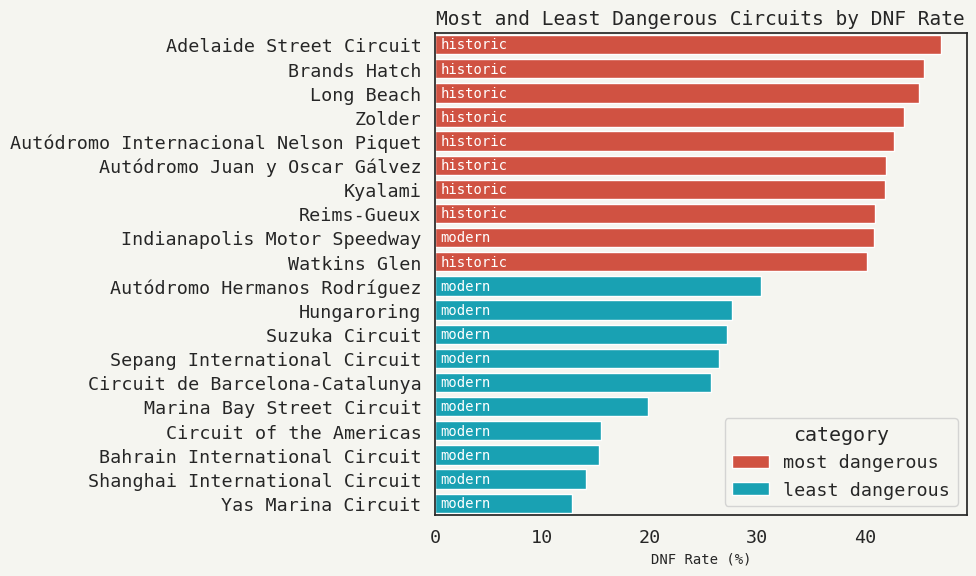

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, y='name', x='dnf_rate', hue='category', ax=ax, palette=f1_palette[:2])

for i, (_, row) in enumerate(df.iterrows()):
    ax.text(0.5, i, row['era'], va='center', fontsize=10, color='white')

ax.set_title('Most and Least Dangerous Circuits by DNF Rate')
ax.set_xlabel('DNF Rate (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The most dangerous circuits are almost entirely historic venues, no longer on the modern F1 calendar. All least dangerous circuits are modern tracks, confirming that safety standards improved.

### Which circuits produce the most and the least overtakes on average?

In [30]:
# We ignore circuits with less than two hundred entries where results can be unstable

query = """ 
WITH circuit_overtake_stats AS(
    SELECT 
    c.circuitId,
    c.circuitRef,
    c.name,
    ROUND(AVG(ABS(re.grid - re.positionOrder)), 2) AS avg_position_change,
    COUNT(*) AS all_entries,
    MIN(ra.year) AS first_appearance,
    MAX(ra.year) AS last_appearance
    FROM circuits c
    INNER JOIN races ra ON ra.circuitId = c.circuitId
    INNER JOIN results re ON re.raceId = ra.raceId
    GROUP BY c.circuitId
    HAVING COUNT(*) >= 200
)
    SELECT * FROM (  
        SELECT
        circuitRef,
        name,
        'most overtakes' AS category,
        avg_position_change,
        all_entries,
        first_appearance,
        last_appearance,
        CASE WHEN last_appearance < 2000 THEN 'historic' ELSE 'modern' END AS era
        FROM circuit_overtake_stats
        ORDER BY avg_position_change DESC
        LIMIT 10 )
    UNION ALL
        SELECT * FROM(
        SELECT
        circuitRef,
        name,
        'least overtakes' AS category,
        avg_position_change,
        all_entries,
        first_appearance,
        last_appearance,
        CASE WHEN last_appearance < 2000 THEN 'historic' ELSE 'modern' END AS era
        FROM circuit_overtake_stats
        ORDER BY avg_position_change ASC
        LIMIT 10 )
    ORDER BY category DESC, avg_position_change DESC
"""

df = pd.read_sql(query, conn)
df

,circuitRef,name,category,avg_position_change,all_entries,first_appearance,last_appearance,era
0,zolder,Zolder,most overtakes,9.97,282,1973,1984,historic
1,jacarepagua,Autódromo Internacional Nelson Piquet,most overtakes,9.96,286,1978,1989,historic
2,long_beach,Long Beach,most overtakes,9.50,220,1976,1983,historic
3,jarama,Jarama,most overtakes,9.47,236,1968,1981,historic
4,adelaide,Adelaide Street Circuit,most overtakes,9.05,312,1985,1995,historic
5,jerez,Circuito de Jerez,most overtakes,8.83,204,1986,1997,historic
6,estoril,Autódromo do Estoril,most overtakes,8.31,367,1984,1996,historic
7,indianapolis,Indianapolis Motor Speedway,most overtakes,8.28,573,1950,2007,modern
8,brands_hatch,Brands Hatch,most overtakes,8.24,374,1964,1986,historic
9,ricard,Circuit Paul Ricard,most overtakes,7.95,481,1971,2022,modern


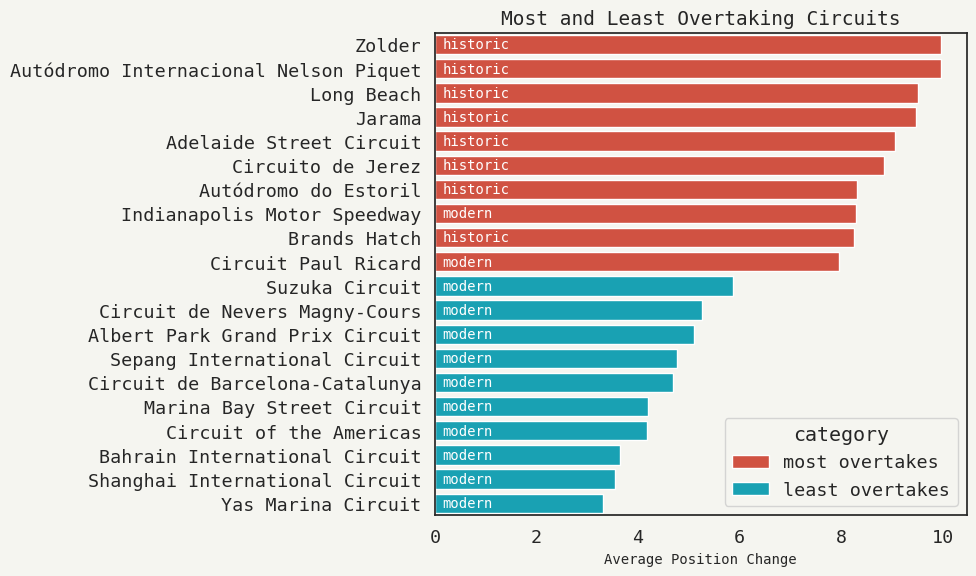

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, y='name', x='avg_position_change', hue='category', 
            ax=ax, palette=f1_palette[:2])

for i, (_, row) in enumerate(df.iterrows()):
    ax.text(0.15, i, row['era'], va='center', fontsize=10, color='white')

ax.set_title('Most and Least Overtaking Circuits')
ax.set_xlabel('Average Position Change')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Historic circuits dominate the most overtaking category, while all least overtaking circuits are modern - suggesting that safer track designs have come at the cost of on-track action.

> Methodology note: Position change (ABS(grid - positionOrder)) is used as a proxy for overtaking. This metric has limitations - large position swings can result from penalties and other factors rather than on-track overtaking. Results should be interpreted as general indicators rather than pure overtaking counts.

## Conclusions

This analysis of 75 years of Formula 1 reveals several key patterns:

**The sport has grown but become more exclusive.** The number of races significantly increased from the 1950s to the 2010s, yet the number of drivers and constructors dropped, reflecting the increasing cost and technological complexity of modern F1.

**Constructor dominance shifts every decade.** Ferrari is the only team to appear in every decade's top 3, while newer teams like Mercedes and Red Bull have risen 
to dominance recently through technical superiority.

**Lewis Hamilton is the greatest driver by every metric**: points, wins, and podiums. However, the points system change in 2010 makes direct comparisons across eras difficult, 
as drivers like Schumacher are underrepresented in the points ranking.

**Modern circuits are safer but less exciting.** Historic venues have significantly higher DNF rates and more overtaking opportunities, suggesting that advances in circuit safety have reduced on-track action as a trade-off.  

Together, these findings paint a picture of evolution of Formula 1. It is faster, safer, and more exclusive than ever before.